# 4 — Model comparison, challenge test, and demo

The main table uses the same held-out real-review test set for both models. The multilingual
challenge contains unseen, team-written sentences that test negation, contrast, Manglish,
emoji, and neutral factual language. Challenge accuracy is diagnostic and is reported
separately from held-out test accuracy.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'dataset').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / 'dataset'
MODEL_DIR = PROJECT_ROOT / 'model'
print('Project root:', PROJECT_ROOT)

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentiment_pipeline import preprocess_for_model, sentiment_emoji
from project_workflow import build_comparison

FIGURE_DIR = PROJECT_ROOT / 'report_figures'
FIGURE_DIR.mkdir(exist_ok=True)

Project root: C:\Users\Fnjtnpcl\Documents\Codex\2026-08-16\referenced-chatgpt-conversation-this-is-an\work\nlp_v31\nlp_sentiment_project_final_fixed (1)\project


In [2]:
comparison = build_comparison(PROJECT_ROOT)
display_table = comparison.copy()
metric_columns = ['Accuracy', 'Precision_weighted', 'Recall_weighted',
                  'F1_weighted', 'F1_macro', 'Pattern_challenge_accuracy']
for column in metric_columns:
    display_table[column] = (display_table[column] * 100).round(2).astype(str) + '%'
display_table

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,F1_macro,Best_parameter,CV_macro_F1,Pattern_challenge_accuracy
0,Complement Naive Bayes,81.19%,82.08%,81.19%,80.6%,80.6%,"alpha=0.05, norm=False, char_weight=0.5",0.820259,100.0%
1,Linear SVM,96.53%,96.55%,96.53%,96.53%,96.53%,C=1.0,0.964056,100.0%


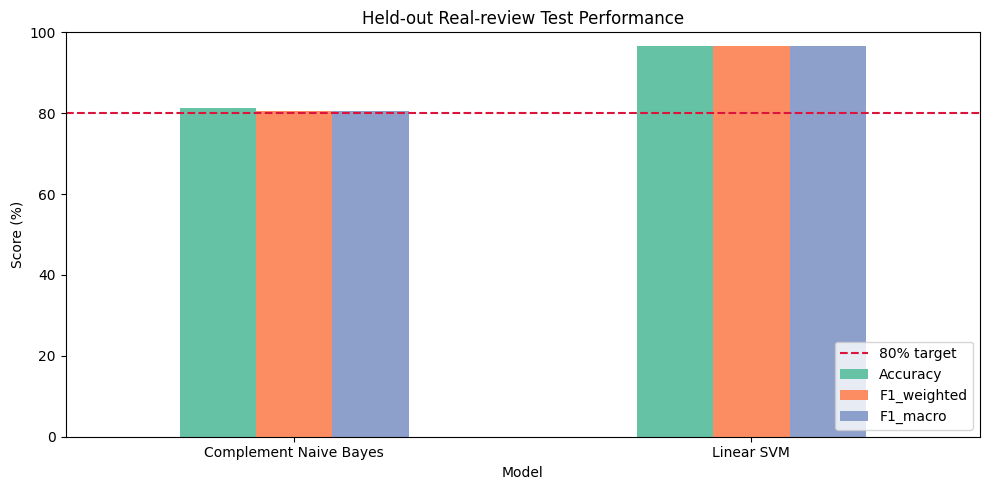

In [3]:
plot_data = comparison.set_index('Model')[['Accuracy', 'F1_weighted', 'F1_macro']] * 100
ax = plot_data.plot(kind='bar', figsize=(10, 5), ylim=(0, 100), color=sns.color_palette('Set2', 3))
ax.axhline(80, color='crimson', linestyle='--', label='80% target')
ax.set_ylabel('Score (%)')
ax.set_title('Held-out Real-review Test Performance')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

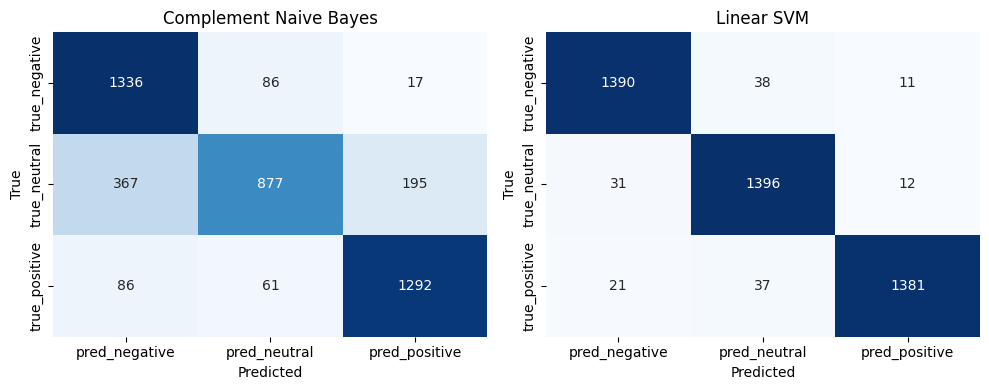

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, filename, title in [
    (axes[0], 'member_a_nb_confusion_matrix.csv', 'Complement Naive Bayes'),
    (axes[1], 'member_b_svm_confusion_matrix.csv', 'Linear SVM'),
]:
    cm = pd.read_csv(DATA_DIR / filename, index_col=0)
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'confusion_matrices.png', dpi=180, bbox_inches='tight')
plt.show()

In [5]:
challenge = pd.read_csv(DATA_DIR / 'multilingual_pattern_challenge_results.csv')
print('Naive Bayes challenge:', f"{challenge['nb_correct'].mean():.2%}")
print('Linear SVM challenge:', f"{challenge['svm_correct'].mean():.2%}")
challenge[['review', 'expected_sentiment', 'nb_prediction', 'svm_prediction']]

Naive Bayes challenge: 100.00%
Linear SVM challenge: 100.00%


,review,expected_sentiment,nb_prediction,svm_prediction
0,"The food was delicious, but I don't like it",negative,negative,negative
1,Food delicious but the taste is horrible,negative,negative,negative
2,"Delivery was fast, however the meal was not fresh",negative,negative,negative
3,Nice packaging yet I cannot recommend this food,negative,negative,negative
4,Looks amazing but tastes disgusting,negative,negative,negative
5,Promo was good tapi app tak boleh guna,negative,negative,negative
6,Delivery fast tapi food tak sedap,negative,negative,negative
7,Makanan nampak cantik tetapi saya tak puas hati,negative,negative,negative
8,Driver cepat tapi service teruk,negative,negative,negative
9,Harga murah but food basi,negative,negative,negative


In [6]:
nb_vectorizer = joblib.load(MODEL_DIR / 'member_a_nb_vectorizer.pkl')
nb_model = joblib.load(MODEL_DIR / 'member_a_naive_bayes.pkl')
svm_vectorizer = joblib.load(MODEL_DIR / 'member_b_svm_vectorizer.pkl')
svm_model = joblib.load(MODEL_DIR / 'member_b_svm.pkl')

def predict_review(review_text, model_name='Linear SVM'):
    processed = preprocess_for_model(review_text)
    if model_name == 'Naive Bayes':
        prediction = str(nb_model.predict(nb_vectorizer.transform([processed]))[0])
    else:
        prediction = str(svm_model.predict(svm_vectorizer.transform([processed]))[0])
    return {'review': review_text, 'model': model_name, 'sentiment': prediction,
            'emoji': sentiment_emoji(prediction), 'processed': processed}

examples = [
    "Food delicious but I don't like it",
    "Delivery fast tapi food tak sedap",
    "Not bad",
    "Tak puas hati",
    "Not gud",
    "Food is not guudd",
    "The order arrived at 7:30 pm.",
]
pd.DataFrame([predict_review(x, model) for x in examples for model in ['Naive Bayes', 'Linear SVM']])

,review,model,sentiment,emoji,processed
0,Food delicious but I don't like it,Naive Bayes,negative,😞,food delicious but i dislike it CONTRAST_FOCUS...
1,Food delicious but I don't like it,Linear SVM,negative,😞,food delicious but i dislike it CONTRAST_FOCUS...
2,Delivery fast tapi food tak sedap,Naive Bayes,negative,😞,delivery fast but food bad tasting CONTRAST_FO...
3,Delivery fast tapi food tak sedap,Linear SVM,negative,😞,delivery fast but food bad tasting CONTRAST_FO...
4,Not bad,Naive Bayes,positive,😊,acceptable good
5,Not bad,Linear SVM,positive,😊,acceptable good
6,Tak puas hati,Naive Bayes,negative,😞,dissatisfied
7,Tak puas hati,Linear SVM,negative,😞,dissatisfied
8,Not gud,Naive Bayes,negative,😞,bad
9,Not gud,Linear SVM,negative,😞,bad


Report the held-out test accuracy and challenge result separately. The weak-supervision
accuracy measures agreement with VADER–TextBlob text labels, not human gold labels.
Star ratings are retained only as audit metadata and are never the prediction target.